### Section 0: Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Section 1: Fetch USD/ETB data

In [3]:
import yfinance as yf

try:
    data = yf.download("USDETB=X", start="2024-08-01", progress=False, multi_level_index=False)
    if not data.empty:
        df = data[["Close"]].rename(columns={"Close": "Rate"})
except Exception as e:
    print("Yahoo Finance failed:", e)

print(df.head())
print(df.shape)

                 Rate
Date                 
2024-08-01  74.250000
2024-08-02  77.050003
2024-08-05  80.018494
2024-08-06  79.589996
2024-08-07  98.279999
(529, 1)


### Section 2: Clean the data

In [4]:
# FX data can have gaps (weekends/holidays have no trading, or an API skipped a day)
# Resample to daily frequency and forward-fill gaps
df = df.asfreq("D")
df["Rate"] = df["Rate"].ffill()

df.dropna(inplace=True)

print(df.isna().sum())
print(df.shape)

Rate    0
dtype: int64
(748, 1)


### Section 3: Plot the raw series

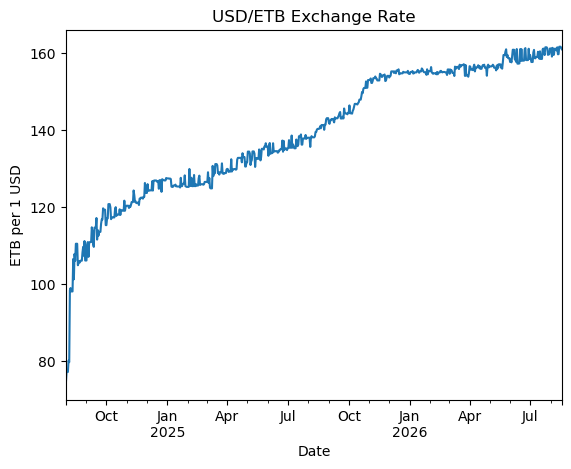

In [5]:
df["Rate"].plot(title="USD/ETB Exchange Rate")
plt.ylabel("ETB per 1 USD");

# What to look for:
# - Trend: almost certainly strong and upward (Birr has been depreciating)
# - Seasonality: FX rates usually do NOT have clean calendar seasonality —
#   the trend is driven by policy/economics, not the time of year

### Section 4: Quick decomposition check

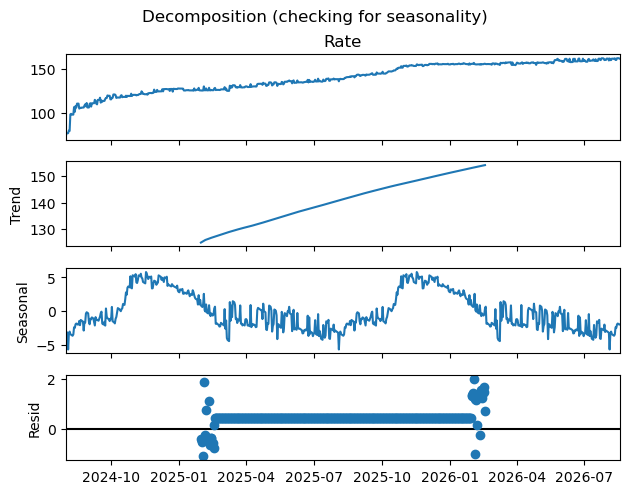

In [6]:
decomp = seasonal_decompose(df["Rate"], model="additive", period=365)
decomp.plot()
plt.suptitle("Decomposition (checking for seasonality)", y=1.02);

# If the "Seasonal" panel looks weak/noisy rather than a clean repeating wave,
# that confirms SARIMA isn't needed here — plain ARIMA is the right tool.

### Section 5: Stationarity check — ADF test

In [7]:
def run_adf_test(series, label=""):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print("=> Reject H0: series is likely STATIONARY\n")
    else:
        print("=> Fail to reject H0: series is likely NON-STATIONARY\n")

run_adf_test(df["Rate"], label="Raw USD/ETB series")

--- ADF Test: Raw USD/ETB series ---
ADF Statistic : -2.4387
p-value       : 0.1311
=> Fail to reject H0: series is likely NON-STATIONARY



### Section 6: Make it stationary

--- ADF Test: Log + First Difference ---
ADF Statistic : -13.5508
p-value       : 0.0000
=> Reject H0: series is likely STATIONARY



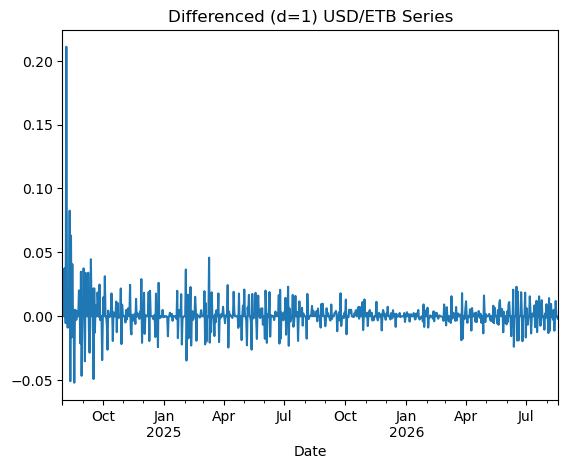

In [8]:
# Log transform first — reduces the impact of the rate's growing scale over time
df["log_rate"] = np.log(df["Rate"])

# First-order differencing to remove the trend
df["log_diff"] = df["log_rate"].diff()

df["log_diff"].plot(title="Differenced (d=1) USD/ETB Series")

run_adf_test(df["log_diff"], label="Log + First Difference")

### Section 7: ACF and PACF plots

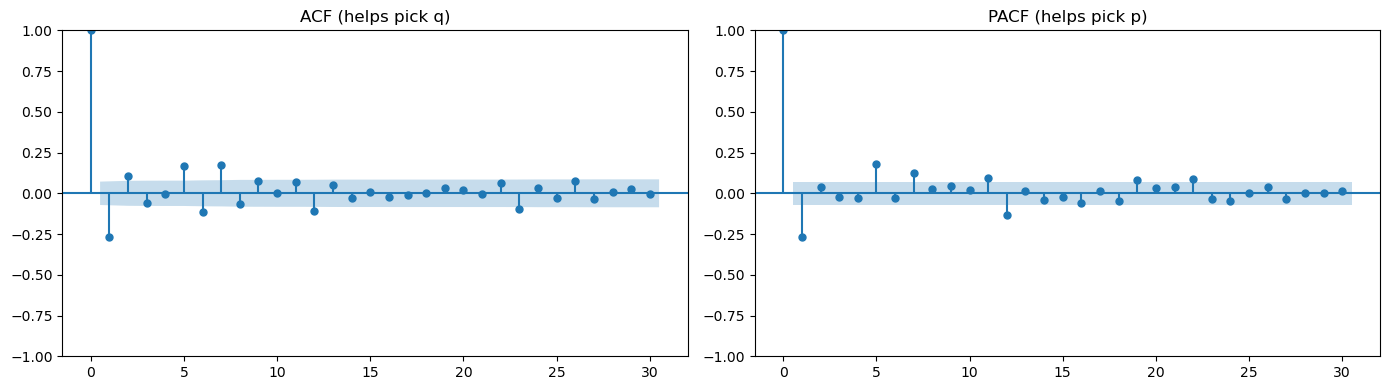

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["log_diff"].dropna(), ax=axes[0], lags=30)
axes[0].set_title("ACF (helps pick q)")

plot_pacf(df["log_diff"].dropna(), ax=axes[1], lags=30, method="ywm")
axes[1].set_title("PACF (helps pick p)")

plt.tight_layout()

### Section 8: Train/test split

In [10]:
# Hold out the last 30 days to test forecast accuracy
train = df["Rate"][:-30]
test = df["Rate"][-30:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 718, Test size: 30


### Section 9: Fit ARIMA

In [11]:
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

print(arima_fit.summary())

# Forecast the next 30 days, plus confidence interval
forecast_result = arima_fit.get_forecast(steps=30)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

                               SARIMAX Results                                
Dep. Variable:                   Rate   No. Observations:                  718
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1283.788
Date:                Tue, 18 Aug 2026   AIC                           2573.576
Time:                        13:22:58   BIC                           2587.301
Sample:                    08-01-2024   HQIC                          2578.876
                         - 07-19-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2762      0.099     -2.792      0.005      -0.470      -0.082
ma.L1         -0.0421      0.102     -0.413      0.679      -0.242       0.158
sigma2         2.1022      0.032     66.483      0.0

### Section 10: Plot forecast vs actual

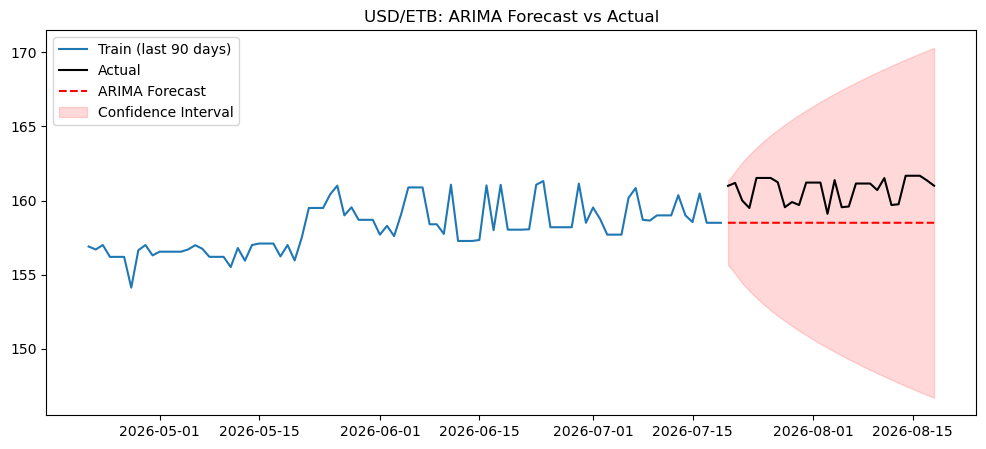

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(train.index[-90:], train[-90:], label="Train (last 90 days)")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(test.index, forecast_mean, label="ARIMA Forecast", linestyle="--", color="red")
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color="red", alpha=0.15, label="Confidence Interval")
plt.legend()
plt.title("USD/ETB: ARIMA Forecast vs Actual");

### Section 11: Evaluate accuracy

In [13]:
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print(f"MAE: {mae:.4f} ETB")
print(f"RMSE: {rmse:.4f} ETB")

MAE: 2.2463 ETB
RMSE: 2.3925 ETB


In [14]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test, forecast_mean) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 1.39%


#### Section 11b: Naive baseline comparison

In [15]:
# The naive baseline: "tomorrow's rate = today's rate" (a pure random walk assumption)
# If your ARIMA model can't beat this, it's not adding real value.

naive_forecast = test.shift(1)
naive_forecast.iloc[0] = train.iloc[-1]  # first prediction uses last known train value

naive_mae = mean_absolute_error(test, naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))
naive_mape = mean_absolute_percentage_error(test, naive_forecast) * 100

print("--- Naive Baseline (today = tomorrow) ---")
print(f"MAE: {naive_mae:.4f} ETB, RMSE: {naive_rmse:.4f} ETB, MAPE: {naive_mape:.2f}%")

print("\n--- ARIMA Model ---")
print(f"MAE: {mae:.4f} ETB, RMSE: {rmse:.4f} ETB, MAPE: {mape:.2f}%")

--- Naive Baseline (today = tomorrow) ---
MAE: 0.7989 ETB, RMSE: 1.1668 ETB, MAPE: 0.50%

--- ARIMA Model ---
MAE: 2.2463 ETB, RMSE: 2.3925 ETB, MAPE: 1.39%


#### Section 11c: Visual comparison of both

Text(0.5, 1.0, 'ARIMA vs Naive Baseline vs Actual')

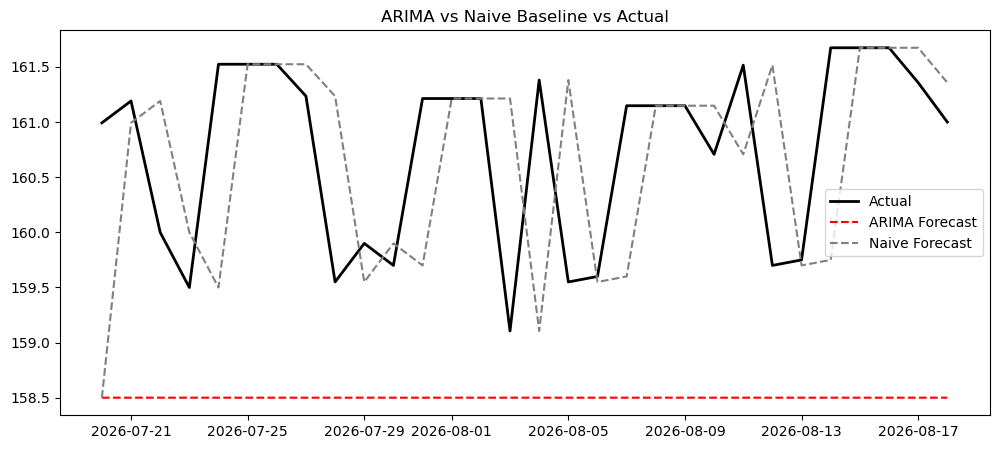

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label="Actual", color="black", linewidth=2)
plt.plot(test.index, forecast_mean, label="ARIMA Forecast", linestyle="--", color="red")
plt.plot(test.index, naive_forecast, label="Naive Forecast", linestyle="--", color="gray")
plt.legend()
plt.title("ARIMA vs Naive Baseline vs Actual")

### Section 12: Forecast the actual future

2026-08-19    161.121999
2026-08-20    161.091843
2026-08-21    161.099297
2026-08-22    161.097455
2026-08-23    161.097910
2026-08-24    161.097797
2026-08-25    161.097825
2026-08-26    161.097818
2026-08-27    161.097820
2026-08-28    161.097820
2026-08-29    161.097820
2026-08-30    161.097820
2026-08-31    161.097820
2026-09-01    161.097820
Freq: D, Name: predicted_mean, dtype: float64


Text(0.5, 1.0, 'USD/ETB: Next 14 Days Forecast')

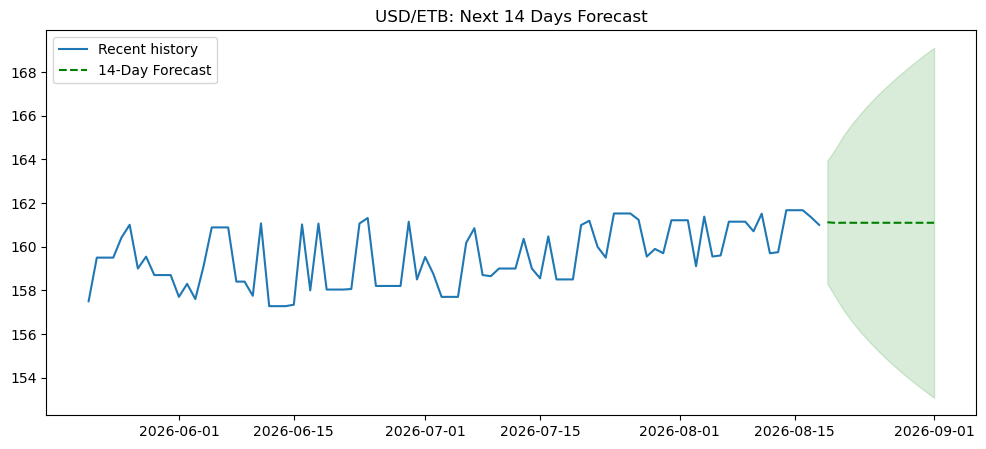

In [17]:
# Refit on the FULL dataset (not just train) to get the best possible forecast going forward
final_model = ARIMA(df["Rate"], order=(1, 1, 1))
final_fit = final_model.fit()

future_forecast = final_fit.get_forecast(steps=14)  # next 14 days
future_mean = future_forecast.predicted_mean
future_conf = future_forecast.conf_int()

print(future_mean)

plt.figure(figsize=(12, 5))
plt.plot(df["Rate"][-90:], label="Recent history")
plt.plot(future_mean, label="14-Day Forecast", linestyle="--", color="green")
plt.fill_between(future_mean.index, future_conf.iloc[:, 0], future_conf.iloc[:, 1],
                  color="green", alpha=0.15)
plt.legend()
plt.title("USD/ETB: Next 14 Days Forecast")

#### Section 12b: Drift-adjusted long-horizon forecast

Text(0.5, 1.0, 'USD/ETB: Drift-Adjusted vs Plain 14-Day Forecast')

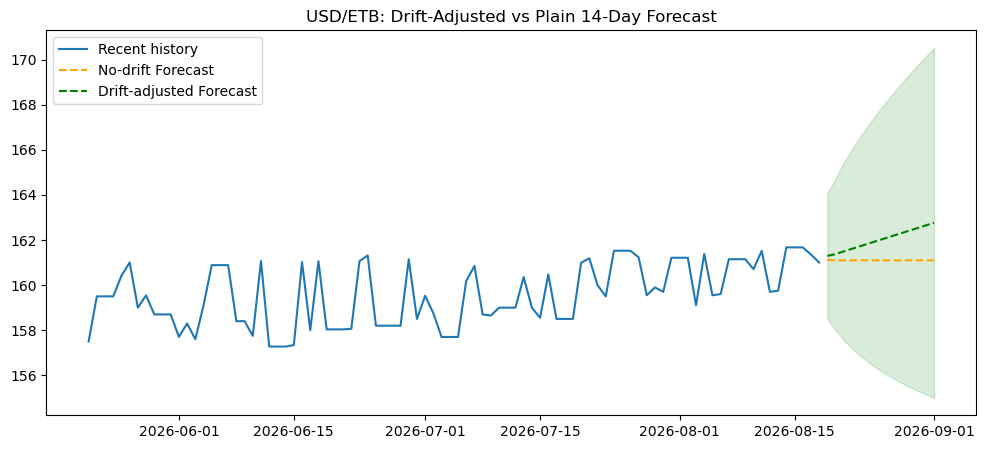

In [18]:
# Refit with a trend/drift term so the forecast doesn't flatten to a flat line
final_model_drift = ARIMA(df["Rate"], order=(1, 1, 1), trend="t")
final_fit_drift = final_model_drift.fit()

future_forecast_drift = final_fit_drift.get_forecast(steps=14)
future_mean_drift = future_forecast_drift.predicted_mean
future_conf_drift = future_forecast_drift.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(df["Rate"][-90:], label="Recent history")
plt.plot(future_mean, label="No-drift Forecast", linestyle="--", color="orange")
plt.plot(future_mean_drift, label="Drift-adjusted Forecast", linestyle="--", color="green")
plt.fill_between(future_mean_drift.index, future_conf_drift.iloc[:, 0], future_conf_drift.iloc[:, 1],
                  color="green", alpha=0.15)
plt.legend()
plt.title("USD/ETB: Drift-Adjusted vs Plain 14-Day Forecast")

In [19]:
import itertools
import warnings
warnings.filterwarnings("ignore")

results = []

p_values = [0, 1, 2]
d_values = [1] 
q_values = [0, 1, 2]

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=(p, d, q))
        fit = model.fit()
        forecast = fit.forecast(steps=len(test))
        mape = mean_absolute_percentage_error(test, forecast) * 100
        results.append((p, d, q, mape))
    except Exception as e:
        continue

results_df = pd.DataFrame(results, columns=["p", "d", "q", "MAPE"]).sort_values("MAPE")
print(results_df)

   p  d  q      MAPE
1  0  1  1  1.370049
5  1  1  2  1.382983
7  2  1  1  1.384469
8  2  1  2  1.388061
4  1  1  1  1.394813
0  0  1  0  1.395339
3  1  1  0  1.395339
6  2  1  0  1.395339
2  0  1  2  1.398723


In [20]:
import joblib

final_model = ARIMA(df["Rate"], order=(0, 1, 1))
final_fit = final_model.fit()

joblib.dump(final_fit, "arima_model.pkl")

# Also save the last known rate and last date — the app needs these
# to build the naive forecast and the forecast date range, without
# needing the full dataset or yfinance call every time
last_info = {
    "last_value": df["Rate"].iloc[-1],
    "last_date": df.index[-1]
}
joblib.dump(last_info, "last_info.pkl")

print("Model and metadata saved.")

Model and metadata saved.


In [21]:
#the app never needs a live yfinance call
df[["Rate"]].to_pickle("history.pkl")
print("History saved.")

History saved.
